In [ ]:
#importing the packages
import pandas as pd
import numpy as np
cancer = pd.read_csv("/content/drive/MyDrive/ovariantotal.csv")
cancer.head()

,AFP,AG,Age,ALB,ALP,ALT,AST,BASO#,BASO%,BUN,...,PCT,PDW,PHOS,PLT,RBC,RDW,TBIL,TP,UA,TYPE
0,3.58,19.36,47,45.4,56,11,24,0.01,0.30,5.35,...,0.09,13.4,1.46,74,2.64,13.7,5.5,73.9,396.4,0
1,34.24,23.98,61,39.9,95,9,13,0.02,0.30,3.21,...,0.30,11.2,1.09,304,4.89,12.7,6.8,72.0,119.2,0
2,1.50,18.40,39,45.4,77,9,18,0.03,0.60,3.80,...,0.13,15.2,0.97,112,4.62,12.0,14.8,77.9,209.2,0
3,2.75,16.60,45,39.2,26,16,17,0.05,0.74,5.27,...,0.25,17.4,1.25,339,4.01,14.6,10.9,66.1,215.6,0
4,2.36,19.97,45,35.0,47,21,27,0.01,0.10,4.89,...,0.28,11.9,0.94,272,4.40,13.4,5.3,66.5,206.0,0


In [ ]:
cancer.shape

(349, 50)

In [ ]:
X=cancer.drop('TYPE',axis=1)
y=cancer['TYPE']

**fit_transform(X)**

**fit(X):** Calculates the minimum and maximum values for each feature (i.e., for each column in X).

**transform(X):** Applies the following formula to each value in X:

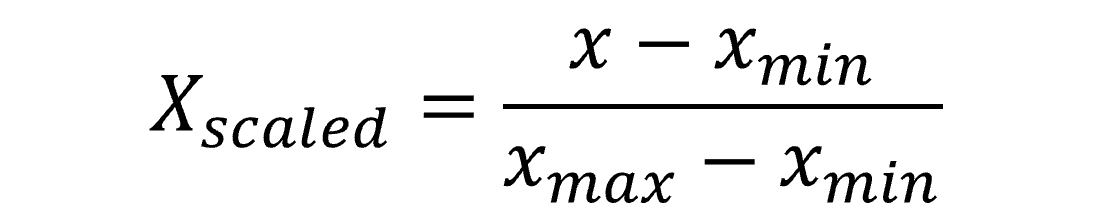

In [ ]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)
print(X_scale)

[[2.45578349e-03 4.85071876e-01 4.70588235e-01 ... 8.37988827e-02
  7.60667904e-01 5.60447761e-01]
 [2.78074070e-02 6.55363067e-01 6.76470588e-01 ... 1.20111732e-01
  7.25417440e-01 4.32835821e-02]
 [7.35908185e-04 4.49686694e-01 3.52941176e-01 ... 3.43575419e-01
  8.34879406e-01 2.11194030e-01]
 ...
 [1.83563615e-03 4.80280133e-01 6.47058824e-01 ... 3.15642458e-01
  6.58627087e-01 2.11753731e-01]
 [1.01704165e-03 7.74788058e-01 2.20588235e-01 ... 2.45810056e-01
  7.99628942e-01 3.53917910e-01]
 [8.26863129e-04 2.50645042e-01 3.52941176e-01 ... 1.62011173e-01
  6.62337662e-01 1.65858209e-01]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scale,y,test_size=0.20,random_state=0)

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(32, activation='relu', input_dim=49))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Given:**

Dataset size = 349 samples

test_size=0.2 → 20% for testing, so
Training set = 80% of 349 = 279 samples (approx.)

batch_size = 32

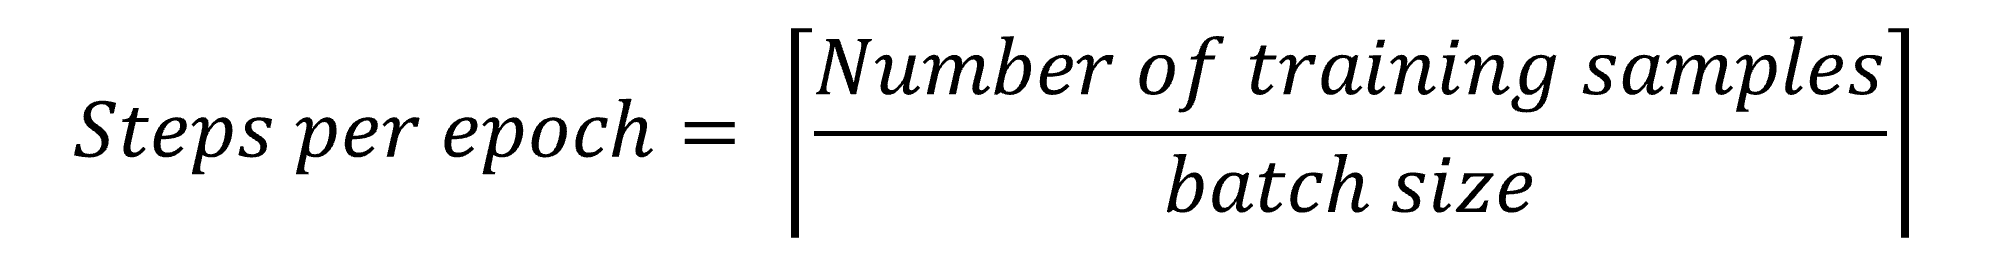

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=32, epochs=15)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5134 - loss: 0.7014
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6028 - loss: 0.6716 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7619 - loss: 0.6497 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7577 - loss: 0.6347 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7290 - loss: 0.6180 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7525 - loss: 0.6020 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7548 - loss: 0.5870 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7392 - loss: 0.5742 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7744 - loss: 0.5395 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7695 - loss: 0.5309 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7878 - loss: 0.4890 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7799 - loss: 0.4856 
Ep

In [ ]:
y_pred=model.predict(X_test)
y_pred


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[0.6956166 ],
       [0.2946664 ],
       [0.69234145],
       [0.10522409],
       [0.8051121 ],
       [0.8608658 ],
       [0.87522113],
       [0.21871091],
       [0.10847906],
       [0.7466163 ],
       [0.7334747 ],
       [0.28958866],
       [0.83270323],
       [0.46649656],
       [0.11138376],
       [0.5524394 ],
       [0.6089235 ],
       [0.78218627],
       [0.89952147],
       [0.498813  ],
       [0.8099526 ],
       [0.8140079 ],
       [0.41399473],
       [0.82286954],
       [0.11483316],
       [0.76054394],
       [0.08680779],
       [0.2089046 ],
       [0.11289124],
       [0.7972676 ],
       [0.5098895 ],
       [0.36557412],
       [0.09772099],
       [0.21411562],
       [0.18500178],
       [0.03532215],
       [0.5627354 ],
       [0.7190877 ],
       [0.23296446],
       [0.32381338],
       [0.84445804],
       [0.77693623],
       [0.74228024],
       [0.7901234 ],
       [0.8343561 ],
       [0.06177657],
       [0.35265154],
       [0.742

In [ ]:
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
import numpy as np
np.column_stack((y_pred, y_test))

array([[1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0,

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[30 11]
 [ 3 26]]
0.8


**Confusion matrix**

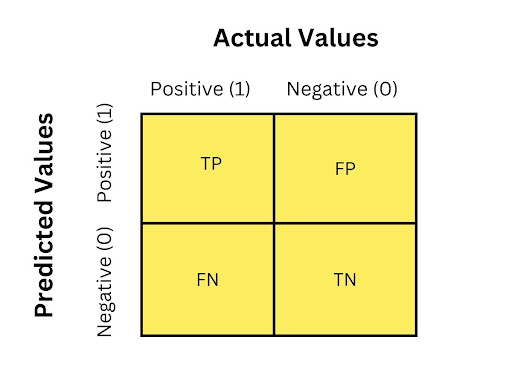

True Positive (TP): Model predicted 1 and actual is 1

False Positive (FP): Model predicted 1, but actual is 0 (Type I error)

False Negative (FN): Model predicted 0, but actual is 1 (Type II error)

True Negative (TN): Model predicted 0 and actual is 0

**Regularization Techniques**

1. Dropout
2. Early stopping
3. L1 and L2 regularization
4. Batch normalization

**1. Dropout**

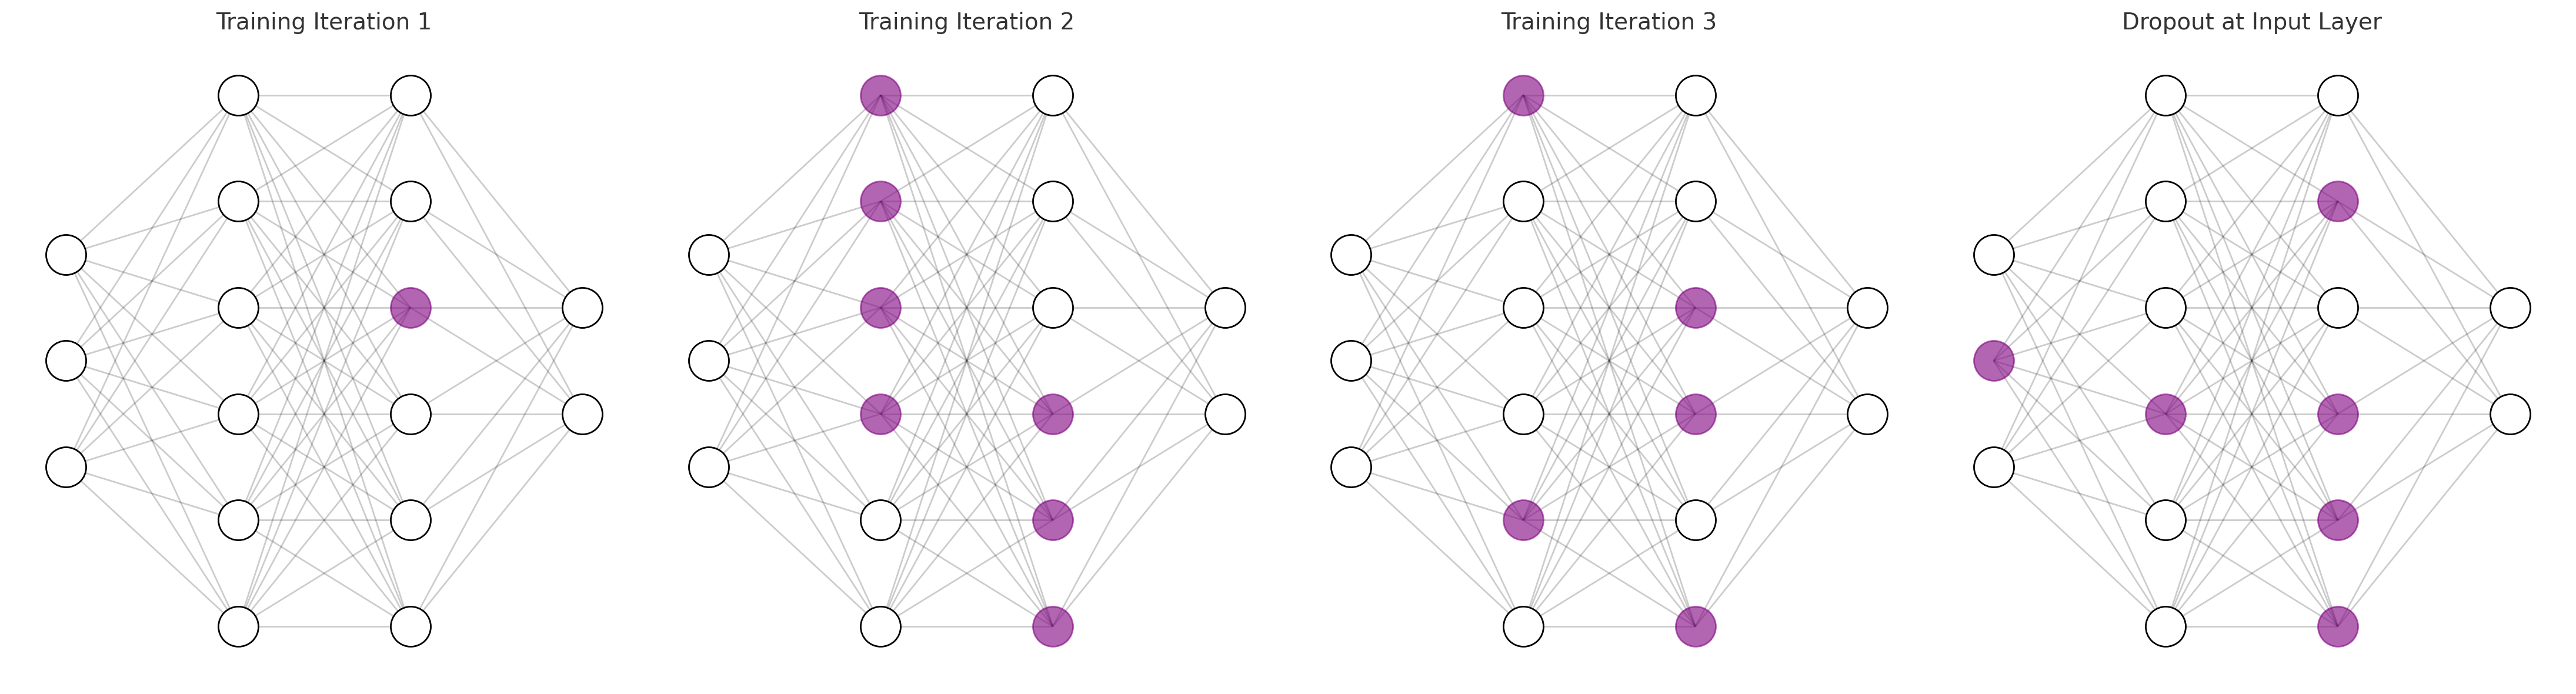

In [ ]:
from tensorflow.keras.layers import Dropout
model = Sequential()

#model.add(Dropout(0.2, input_dim=49))
#model.add(Dense(32, activation='relu'))

model.add(Dense(32, activation='relu', input_dim=49))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

#Output layer
model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=32, epochs=15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5135 - loss: 0.7016
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5586 - loss: 0.6817 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5721 - loss: 0.6735 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6722 - loss: 0.6515 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6549 - loss: 0.6271 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6977 - loss: 0.6107 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7194 - loss: 0.6057 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6986 - loss: 0.6015 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6956 - loss: 0.5901 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7494 - loss: 0.5651 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7648 - loss: 0.5312 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7905 - loss: 0.5130 
Epoch 13/15
9

In [ ]:
y_pred=model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[30 11]
 [ 3 26]]
0.8


**Early stopping**

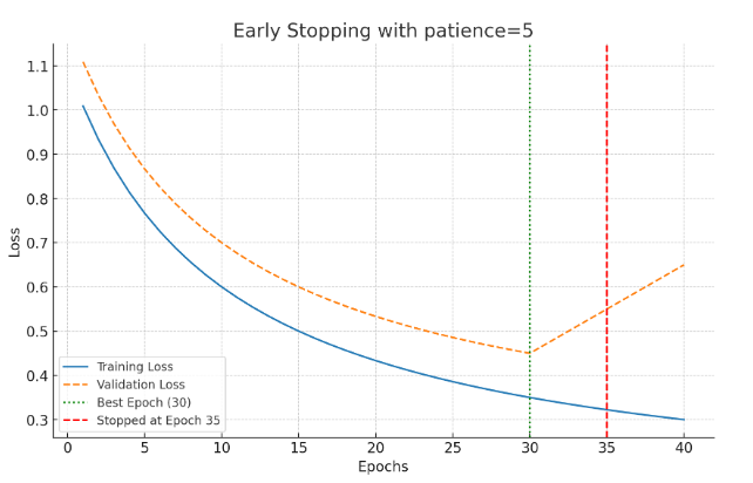

In [ ]:
from keras.callbacks import EarlyStopping
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=49))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#watches the validation-loss metric during training.
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2, #20 % of X_train is set aside internally for validation (so effectively 64 % train + 16 % validation + 20 % test).
    callbacks=[early_stop],
    verbose=1
)

# Evaluate performance
y_pred=model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.4824 - loss: 0.7097 - val_accuracy: 0.5714 - val_loss: 0.6887
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5662 - loss: 0.6856 - val_accuracy: 0.6607 - val_loss: 0.6739
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6669 - loss: 0.6580 - val_accuracy: 0.6786 - val_loss: 0.6560
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6392 - loss: 0.6445 - val_accuracy: 0.7143 - val_loss: 0.6378
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6783 - loss: 0.6281 - val_accuracy: 0.7143 - val_loss: 0.6235
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6536 - loss: 0.6240 - val_accuracy: 0.6964 - val_loss: 0.6133
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6903 - loss: 0.5961 - val_accuracy: 0.7143 - val_loss: 0.5978
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7562 - loss: 0.5696 - val_accuracy: 0.7143 - val_loss: 0.5881
Epoc

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[32  9]
 [ 2 27]]
0.8428571428571429


**L1 and L2 regularization**

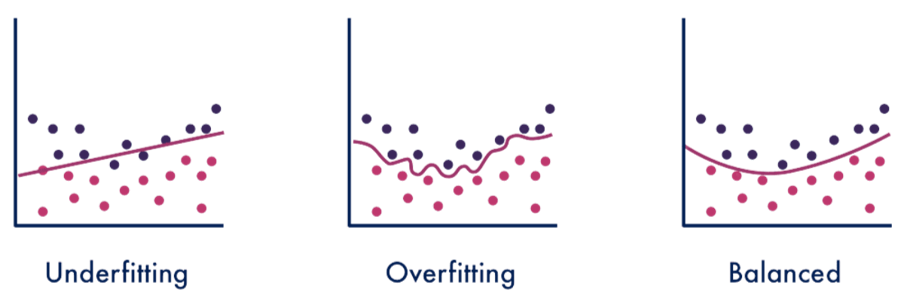

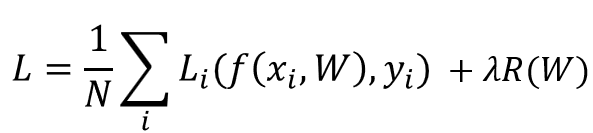

In [ ]:
from tensorflow.keras import layers, models, regularizers

model = Sequential()

model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.L1(0.001), input_dim=49))
model.add(Dense(32, kernel_regularizer=regularizers.L1(0.001), activation='relu'))

#Output layer
model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=32, epochs=15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4518 - loss: 1.0679
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5722 - loss: 1.0370 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6782 - loss: 1.0114 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7647 - loss: 0.9763 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7217 - loss: 0.9485 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7463 - loss: 0.9045 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7724 - loss: 0.8657 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7851 - loss: 0.8459 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7852 - loss: 0.8094 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7946 - loss: 0.7869 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7816 - loss: 0.7483 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8105 - loss: 0.7509 
Epoch 13/15
9

In [ ]:
y_pred=model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[33  8]
 [ 3 26]]
0.8428571428571429


In [ ]:
from tensorflow.keras import layers, models, regularizers

model = Sequential()
model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.L2(0.001), input_dim=49))
model.add(Dense(32, kernel_regularizer=regularizers.L2(0.001), activation='relu'))

#Output layer
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=32, epochs=15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4823 - loss: 0.7735
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6317 - loss: 0.7416 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7121 - loss: 0.7190 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6990 - loss: 0.7025 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7148 - loss: 0.6839 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7541 - loss: 0.6491 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6976 - loss: 0.6446 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7259 - loss: 0.6242 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7295 - loss: 0.6142
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7547 - loss: 0.5673 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7446 - loss: 0.5720 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7596 - loss: 0.5421 
Epoch 13/15


In [ ]:
y_pred=model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[30 11]
 [ 4 25]]
0.7857142857142857


In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout

# Define the Sequential model
model = Sequential()

# Input layer + 1st hidden layer
model.add(Dense(32, activation='relu', input_dim=49))
model.add(BatchNormalization())          # Normalize activations to stabilize learning
model.add(Dropout(0.3))                  # Optional: Dropout for regularization

# 2nd hidden layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())          # Normalize the second layer's activations
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))  # Binary classification output

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=32, epochs=15)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4941 - loss: 0.9027
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6658 - loss: 0.6681 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7011 - loss: 0.6034 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6251 - loss: 0.6813 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7247 - loss: 0.5546 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7247 - loss: 0.5752 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7630 - loss: 0.4875 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7214 - loss: 0.6054 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7535 - loss: 0.4741 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7667 - loss: 0.5297 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7464 - loss: 0.5120 
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.4761 
Ep

In [ ]:
y_pred=model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = y_pred.astype(int)
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[24 17]
 [ 1 28]]
0.7428571428571429
